# Neural correlates of LDA 1 — one figure, one correction

Three neural metrics, four tests each, in one place. The metrics used to live in three
notebooks that each re-read the same ~400 firing-rate files and each carried its own copy of
the same test function:

| row | notebook it comes from |
|---|---|
| Firing rate | `neural/firing_rate/fr_psth_ldabin.ipynb` |
| Fano factor | `neural/fano_factor/ff_psth_ldabin.ipynb` |
| Noise correlation ($r_{SC}$) | `neural/noise_correlations/noise_corr_psth_lda.ipynb` |

and the columns are the four things asked of each metric:

| column | what it is |
|---|---|
| **Time course** | the descriptive PSTH per LDA-1 bin, with the two analysis windows marked |
| **Baseline** | the metric in the pre-stimulus window |
| **Post-stimulus** | the metric in the post-stimulus window — one window for all three rows |
| **Response magnitude** | the pre → post change (evoked rate / FF quench / $r_{SC}$ quench) |
| **Response onset** | *when* the change starts — Fano factor only |

**One pre and one post window for every row.** The noise-correlation notebook measured its
post-stimulus window over 0–0.2 s while Fano factor and firing rate used 0.1–0.3 s, so the
"post-stimulus" column would otherwise have meant a different stretch of time in the bottom row
than in the two above it. All three now use 0.1–0.3 s (and a half-open interval, so it is
literally the same set of time bins). The old window is still computed, as
`r_sc_post_legacy` / `r_sc_quench_legacy`, purely so the reproduction check below can test like
for like.

**The statistics are not re-derived here.** `lda1_neural_metrics.age_effect_test` is the
three notebooks' own function, moved rather than rewritten: GLM slope of `lda_1` as the test
statistic, a permutation null that shuffles `lda_1` across **sessions** with rows inside a
session kept yoked (n = 2000), and a partial-correlation JZS Bayes factor via `pingouin` after
Frisch–Waugh–Lovell residualising. The unit of analysis stays what each metric is naturally
computed at — single neuron for FF and FR, session × region for $r_{SC}$ — and so do the
covariates. What is new here is only that the ten tests are corrected **as one family**, which
is impossible while they live in three notebooks.

There is no test for firing-rate onset timing. That column is left empty rather than filled
with firing rate's `peak_latency`, which is the timing of the *peak* rather than of the onset,
and is computed on an SNR-gated subset of excited neurons with extra covariates — not the same
quantity as the FF quench onset beside it.

In [1]:
"""
SHARED FIGURE STYLE -- run this cell first
=========================================
Colours, panel sizes, type and saving all come from paper-individuality/paper_style.py, so
this figure matches the LDA, syllable and GLM-HMM figures and the poster. Nothing below
hardcodes a hex colour or a point size, so one switch re-renders the notebook:

    ps.use('poster')   big type, big panels -- what a poster needs
    ps.use('paper')    journal column widths, 7 pt type
"""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (str(_root), str(_root / 'neural')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps

ps.use('poster')     # 'poster' = big type for a poster; 'paper' = journal sizes

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

In [2]:
"""
IMPORTS
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import importlib
import lda1_neural_metrics as nm      # neural/lda1_neural_metrics.py -- compute + the test
# RELOAD ON EVERY RUN. A Jupyter kernel keeps the version of a module it imported FIRST:
# `import lda1_neural_metrics` on a later run is a no-op if the name is already bound, so
# edits to the .py file are silently ignored until the kernel is restarted. That failure is
# invisible -- the notebook runs fine and produces the OLD numbers. The tell is the cache
# name: an old module writes 'lda1_neural_<date>', the current one writes what
# nm.cache_tag() prints below.
importlib.reload(nm)

cfg = nm.default_config()
N_BINS = 5                            # LDA-1 bins, as cut in the LDA file

# ===========================================================================
# DATA QUALITY -- every knob in one place
# ===========================================================================
# Set here rather than in the module, so the module's own defaults stay the path that
# reproduces the three source notebooks. Every setting below is recorded in the cache
# NAME (printed at the bottom of this cell), so two different settings can never
# overwrite each other's tables, and load_tables(cfg=cfg) refuses a cache built under
# different ones. CHANGING ANY OF THESE NEEDS `RECOMPUTE = True` IN THE NEXT CELL.

# --- the firing-rate floor -------------------------------------------------
# ONE floor, in Hz, for all three metrics. They used to disagree in units that hid the
# disagreement: firing rate gated at 1 Hz, Fano factor at 0.5 spikes per 0.204 s window
# -- which is 2.45 Hz, so 2.45x stricter -- and r_SC at nothing at all. That last one is
# how a 25-neuron MOp population with a median rate of 0.22 Hz produced an r_SC of
# -0.279, a value below the -1/(n-1) floor a real correlation matrix can reach. FF's
# count gate is now DERIVED from this number and the window length, not set separately.
FIRING_RATE_FLOOR = 1.0       # Hz

# WHERE THAT RATE IS MEASURED:
#   'session'  the spike sorter's own whole-recording firing rate, from the unit QC
#              table -- this is what Zang et al. gate on (`clus_df['firing_rate'] > 1`).
#              It knows nothing about the trial windows or the stimulus, so it CANNOT
#              select neurons on their response, which makes FLOOR_REQUIRE below
#              irrelevant. Needs the QC table (python fetch_unit_qc.py); a neuron with
#              no QC row is dropped.
#   'window'   the neuron's mean rate in the pre / post analysis windows, gated per
#              FLOOR_REQUIRE. Measured from the same data the metrics are.
FLOOR_SOURCE = 'session'

# Which window(s) a neuron must clear the floor in:
#   'both'    baseline AND response -- conservative, the current default
#   'pre'     BASELINE ONLY. Use this if the worry is selecting neurons on their
#             RESPONSE: gating on the post window conditions on a stimulus-driven
#             quantity, and the fraction of responsive neurons does track lda_1, so the
#             cohort would shift along the very axis being tested.
#   'post' | 'either'
FLOOR_REQUIRE = 'both'

UNIFORM_FLOOR = True          # False = each metric's ORIGINAL gate (reproduction path)

# --- presence ratio --------------------------------------------------------
# The fraction of 10 s bins of the whole recording in which a unit fired at least one
# spike. NOT part of IBL's `label`, which is the mean of exactly three criteria (sliding
# refractory period, noise cutoff, median amplitude > 50 uV) -- so `good_units=True`,
# which is how the firing-rate files were built, lets through units that drifted off the
# probe partway through. Those matter most for the Fano factor: their counts come from
# two distributions, inflating across-trial variance by an amount that depends on when
# the unit was lost. 0.90 is Allen's convention, 0.95 is Zang et al.
# False needs no QC table at all -- which is how you see the same figure with and
# without the filter.
USE_PRESENCE_RATIO = True
PRESENCE_RATIO = 0.90

# --- population size -------------------------------------------------------
MIN_NEURONS = 15              # per region, per session -- ALL metrics
# r_SC only, if it should be stricter. It is a PAIRWISE metric: 15 neurons is 105 pairs,
# 30 is 435, and the estimate's noise falls with the number of pairs -- so a count that
# is generous for a per-neuron metric is thin for this one. None = use MIN_NEURONS.
MIN_NEURONS_RSC = None

# r_SC's trial-completeness window is left at the module default, (-0.35, 0.65): the fix
# for discarding half of every session's trials over a NaN at t = -0.5 s that no r_SC
# window reads. None restores the old all-90-bins behaviour.

cfg['MIN_FR_HZ'] = FIRING_RATE_FLOOR
cfg['FR_FLOOR_REQUIRE'] = FLOOR_REQUIRE
cfg['FR_FLOOR_SOURCE'] = FLOOR_SOURCE
cfg['UNIFORM_FR_FLOOR'] = UNIFORM_FLOOR
cfg['MIN_PRESENCE_RATIO'] = PRESENCE_RATIO if USE_PRESENCE_RATIO else None
cfg['MIN_NEURONS'] = MIN_NEURONS
cfg['MIN_NEURONS_RSC'] = MIN_NEURONS_RSC
# ===========================================================================

print(f"cohort: {'all regions' if not cfg['KEEP'] else str(len(cfg['KEEP'])) + '-region KEEP list'}"
      f" | {cfg['N_PERM']} permutations | windows: pre {cfg['PRE_WINDOW']}, post {cfg['POST_WINDOW']}"
      f" (r_SC: {cfg['RSC_PRE_WINDOW']}, {cfg['RSC_POST_WINDOW']})")
print(f"QC: rate floor {cfg['MIN_FR_HZ']} Hz from the {cfg['FR_FLOOR_SOURCE']} rate"
      f"{chr(32) + 'in ' + repr(cfg['FR_FLOOR_REQUIRE']) + ' window(s)' if cfg['FR_FLOOR_SOURCE'] != 'session' else ''}"
      f" ({'same for all three metrics' if cfg['UNIFORM_FR_FLOOR'] else 'per-metric, original'})"
      f"\n    presence ratio {cfg['MIN_PRESENCE_RATIO'] or 'OFF'}"
      f" | min neurons {cfg['MIN_NEURONS']}"
      f"{' (r_SC ' + str(cfg['MIN_NEURONS_RSC']) + ')' if cfg['MIN_NEURONS_RSC'] else ''}"
      f" | r_SC trials complete over {cfg['RSC_COMPLETE_WINDOW']}"
      f"\ncache: {nm.cache_tag(cfg)}")


cohort: 20-region KEEP list | 2000 permutations | windows: pre (-0.2, 0.0), post (0.1, 0.3) (r_SC: (-0.2, 0.0), (0.1, 0.3))
QC: rate floor 1.0 Hz from the session rate (same for all three metrics)
    presence ratio 0.9 | min neurons 15 | r_SC trials complete over (-0.35, 0.65)
cache: lda1_neural_pr90_fr10_sess


## The metric tables

One pass over the ~400 firing-rate pkl files produces all three metric tables plus the
descriptive time courses. It takes a while, so it is cached to parquet in `neural/lda1_tables/`
and re-read on later runs — set `RECOMPUTE = True` to force the pass (after changing a window,
a gate, or the region list).

`compute_tables` applies **no** cohort filter: it keeps every region with at least
`MIN_NEURONS` neurons and records each session's goCue validation flag. The cohort is imposed
afterwards by `apply_cohort`, which is what lets the same compute serve both the reproduction
check and the figure.

In [3]:
RECOMPUTE = False    # True re-reads every pkl file (slow); False uses the newest cache

if RECOMPUTE:
    tables_raw = nm.compute_tables(cfg)
    nm.save_tables(tables_raw, cfg)          # named for the QC settings -- nm.cache_tag
else:
    # cfg=cfg means "the cache built under THESE QC settings", so switching
    # USE_PRESENCE_RATIO and forgetting to recompute raises instead of quietly handing
    # back the other version's tables
    tables_raw = nm.load_tables(cfg=cfg)

tsec = tables_raw['time']['tsec'].values

FileNotFoundError: no cached tables for this QC configuration ('lda1_neural_pr90_fr10_sess') in /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/neural/lda1_tables. Set RECOMPUTE = True to build it, or pass cfg=None to load whatever cache is newest regardless of how it was gated.

## Check: does this reproduce the three notebooks?

Before the unified cohort, the same compute is run through each metric's **original** filters
(`cohort='legacy'`: the 48-region list for Fano factor, every region for firing rate,
`'root'` retained for $r_{SC}$ as its notebook had it, the goCue check for $r_{SC}$ only, and
$r_{SC}$ tested on its **original** 0–0.2 s post window rather than the shared one).
The reference values are transcribed from the three notebooks' own stored output, so this is a
real check and not a restatement of what was just computed.

**Firing rate and Fano factor reproduce to every printed digit** — all seven tests, including
the quench onset (10 964 of 10 995 neurons carry an onset time, exactly as that notebook
reported).

**$r_{SC}$ does not, and is not expected to.** Every firing-rate pkl file in
`data/firing_rates/` was regenerated on **2026-08-26**. The Fano-factor and firing-rate
notebooks were re-run after that and their stored numbers are current; the noise-correlation
notebook's stored output predates it, so its reference values were computed from a previous
build of the spike data (1123 session-region rows over 244 sessions, against 943 over 238 in
the current files). The direction, ordering and rough magnitude of all three $r_{SC}$ effects
carry over — baseline null, post-stimulus negative, quench positive — but the exact numbers in
`noise_corr_psth_lda.ipynb` are stale and the ones below supersede them.

In [ ]:
# metric -> (r_partial, BF10, p_perm) as printed by the three source notebooks
PUBLISHED = {
    ('Firing rate', 'Baseline'):       (+0.0300, 1.90e2, 0.0690),
    ('Firing rate', 'Post-stimulus'):  (+0.0227, 2.62e0, 0.1475),
    ('Firing rate', 'Response magnitude'):      (+0.0181, 3.25e-1, 0.0920),
    ('Fano factor', 'Baseline'):       (-0.0083, 1.75e-2, 0.7410),
    ('Fano factor', 'Post-stimulus'):  (-0.0620, 1.67e7, 0.0215),
    ('Fano factor', 'Response magnitude'):      (+0.0542, 1.18e5, 0.0040),
    ('Fano factor', 'Response onset'):   (-0.0643, 8.35e7, 0.0000),
    ('Noise correlation', 'Baseline'):      (-0.0667, 3.35e-1, 0.0985),
    ('Noise correlation', 'Post-stimulus'): (-0.1140, 1.98e1, 0.0080),
    ('Noise correlation', 'Response magnitude'):     (+0.1402, 4.81e2, 0.0000),
}

# The published numbers were computed with NO presence-ratio gate and with r_SC demanding
# all 90 bins. With either turned on this stops being a like-for-like check, so say so
# rather than letting a row print 'DIFFERS' as though something had broken.
_qc_on = (cfg.get('MIN_PRESENCE_RATIO') is not None
          or cfg.get('RSC_COMPLETE_WINDOW') is not None
          or cfg.get('UNIFORM_FR_FLOOR', False))
if _qc_on:
    print('NOTE: data-quality gates are on --\n'
          f"        presence ratio      {cfg['MIN_PRESENCE_RATIO']}\n"
          f"        r_SC completeness   {cfg['RSC_COMPLETE_WINDOW']}\n"
          f"        uniform rate floor  {cfg['UNIFORM_FR_FLOOR']} ({cfg['MIN_FR_HZ']} Hz)\n"
          '      The published numbers predate all three, so differences below are\n'
          '      EXPECTED -- the uniform floor alone changes every Fano-factor row, since\n'
          '      FF was gated at 2.45 Hz when those numbers were produced. To reproduce\n'
          '      them: MIN_PRESENCE_RATIO=None, RSC_COMPLETE_WINDOW=None,\n'
          '      UNIFORM_FR_FLOOR=False, then recompute.')

tables_legacy = nm.apply_cohort(tables_raw, cfg, 'legacy')
# r_SC on its own original post window, so the check is against like for like
res_legacy = nm.run_tests(tables_legacy, cfg, verbose=False, rsc_legacy=True)

print(f"\n{'metric':<18}{'test':<15}{'r_partial':>22}{'p_perm':>18}{'n':>8}")
for _, r in res_legacy.iterrows():
    ref = PUBLISHED.get((r['metric'], r['test']))
    if ref is None:
        continue
    dr = r['r_partial'] - ref[0]
    dp = r['p_perm'] - ref[2]
    # r_SC's reference predates the 2026-08-26 rebuild of the firing-rate files, so a
    # mismatch there is expected and is labelled as such rather than as a failure
    stale = r['metric'] == 'Noise correlation'
    flag = ('ok' if abs(dr) < 5e-3 else
            'QC gates on' if _qc_on else 'stale ref' if stale else 'DIFFERS')
    print(f"{r['metric']:<18}{r['test']:<15}"
          f"{r['r_partial']:>10.4f} (pub {ref[0]:+.4f}){r['p_perm']:>10.4f} (pub {ref[2]:.4f})"
          f"{r['n']:>8}   {flag}")

NOTE: data-quality gates are on --
        presence ratio      0.8
        r_SC completeness   (-0.35, 0.65)
        uniform rate floor  True (1.0 Hz)
      The published numbers predate all three, so differences below are
      EXPECTED -- the uniform floor alone changes every Fano-factor row, since
      FF was gated at 2.45 Hz when those numbers were produced. To reproduce
      them: MIN_PRESENCE_RATIO=None, RSC_COMPLETE_WINDOW=None,
      UNIFORM_FR_FLOOR=False, then recompute.
LDA file: mouse_LDA_5_bins_25_18-09-2026
  attached lda_2, lda_3 to the metric tables
cohort 'legacy': fr 24743 rows / 220 sessions | ff 11721 rows / 186 sessions | rsc 726 rows / 219 sessions

metric            test                        r_partial            p_perm       n
Firing rate       Baseline          -0.0363 (pub +0.0300)    0.0330 (pub 0.0690)   24743   QC gates on
Firing rate       Post-stimulus     -0.0126 (pub +0.0227)    0.4065 (pub 0.1475)   24743   QC gates on
Firing rate       Response mag

## The tests, on one cohort

`cohort='common'` puts all three rows on the same footing: one region list (`cfg['KEEP']`, the
48-region list by default) and one session set — the goCue-validated sessions that survive in
all three tables. That is stricter than any of the three notebooks applied on its own, and it
is what makes a row of the figure comparable to the row above it.

**Multiple comparisons — corrected within each metric.** `cfg['FDR_FAMILY'] = 'metric'` makes
each row of the figure its own family: the four Fano-factor tests are corrected among
themselves, the three firing-rate tests among themselves, the three $r_{SC}$ tests among
themselves. That is the family a reader comparing *windows within one metric* is exposed to —
"FF variability tracks LDA 1, and here is which window" is a claim about four tests, not ten.

The family of ten is computed anyway and printed in the column beside it (`q_all`), because it
is the family a reader scanning the whole grid for *any* effect is exposed to; switch which one
the figure annotates with `cfg['FDR_FAMILY'] = 'all'`. The two differ where they matter: with
four FF tests rather than ten the FF post-stimulus effect survives, and the $r_{SC}$ quench
lands just the wrong side of .05 either way.

The correction is applied to `p_perm`, not to the Bayes factor: BF10 is computed at the row
`n` — thousands of neurons — while the permutation resamples ~200 session labels, which is why
a BF of $10^7$ can sit next to *p* = .02. The permutation *p* is the one of the two that
respects the level `lda_1` actually varies at.

`p_perm = 0` is a bound, not a zero: with 2000 permutations it means no permutation reached the
observed slope, so it prints as `<0.0005`.

In [ ]:
# WHICH LDA COMPONENTS TO TEST AND PLOT. ['lda_1'] reproduces the paper exactly; adding
# 'lda_2'/'lda_3' repeats the whole grid on the other discriminants, which is worth doing
# because the leading eigenvalues are near-tied -- LD1/LD2/LD3 rotate among themselves, so
# LD1 is one slice of a subspace rather than the only direction in it.
#
# THE CORRECTION DOES NOT SPAN COMPONENTS. Each component's grid is its own family (ten
# tests, corrected as cfg['FDR_FAMILY'] says). Testing three components is thirty tests,
# and nothing here corrects across them -- so a q from the LD2 grid answers "among the LD2
# tests", not "among everything I looked at". Say which when quoting one.
COMPONENTS = ['lda_1']          # e.g. ['lda_1', 'lda_2', 'lda_3']

tables = nm.apply_cohort(tables_raw, cfg, 'common')

res_by_comp = {}
for _pred in COMPONENTS:
    print(f'--- {_pred} ---')
    res_by_comp[_pred] = nm.run_tests(tables, cfg, predictor=_pred)
# `res` stays the FIRST component's frame, so every cell below this one is unchanged for
# the default single-component run; res_all carries every component for the csv.
res = res_by_comp[COMPONENTS[0]]
res_all = pd.concat(res_by_comp.values(), ignore_index=True)

print()
for _pred, _r in res_by_comp.items():
    print(f'== {_pred} ==')
    print(nm.results_table(_r, p_floor=1.0 / cfg['N_PERM']))
print(f"\n{cfg['FDR_METHOD']} at alpha = {cfg['ALPHA']}, family = '{cfg['FDR_FAMILY']}'"
      f" ({', '.join(f'{m}: {n}' for m, n in res.groupby('metric').size().items())})")
print(f"  within-metric: {int((res['q_fdr_metric'] < cfg['ALPHA']).sum())} of {len(res)} survive")
print(f"  all ten      : {int((res['q_fdr_all'] < cfg['ALPHA']).sum())} of {len(res)} survive")
print(f"  uncorrected  : {int((res['p_perm'] < cfg['ALPHA']).sum())} of {len(res)} significant")
for _, r in res[res['q_fdr_metric'] < cfg['ALPHA']].iterrows():
    print(f"    survives within-metric: {r['metric']} / {r['test']} "
          f"(q = {r['q_fdr_metric']:.4f}, q_all = {r['q_fdr_all']:.4f})")

LDA file: mouse_LDA_5_bins_25_18-09-2026
  attached lda_2, lda_3 to the metric tables
cohort 'common': fr 13717 rows / 186 sessions | ff 11721 rows / 186 sessions | rsc 398 rows / 185 sessions
--- lda_1 ---
  Firing rate        Baseline       log_fr_pre ~ lda_1 + C(region) + n_trials
  Firing rate        Post-stimulus  log_fr_post ~ lda_1 + C(region) + n_trials
  Firing rate        Response magnitude fr_evoked ~ lda_1 + C(region) + n_trials
  Firing rate        Response onset fr_onset_time ~ lda_1 + C(region) + n_trials
  Fano factor        Baseline       log_ff_pre ~ lda_1 + C(region) + n_trials
  Fano factor        Post-stimulus  log_ff_post ~ lda_1 + C(region) + n_trials
  Fano factor        Response magnitude ff_quench ~ lda_1 + C(region) + n_trials
  Fano factor        Response onset quench_onset_time ~ lda_1 + C(region) + n_trials
  Noise correlation  Baseline       r_sc_pre ~ lda_1 + C(region) + n_trials + n_neurons
  Noise correlation  Post-stimulus  r_sc_post ~ lda_1 + C(regio

## The figure

Rows are metrics, columns are the four tests, and the leftmost panel of each row is the time
course those tests read their windows off — so the reader can see *where* on the curve
"baseline" and "post-stimulus" are before being shown a correlation with either.

It is drawn in **poster mode** at the same cell size as `4_mice/LDA_behavior`'s correlation
grid (4.0 × 3.65 in per cell, square plotting area), so the type-to-panel ratio matches the
panels it will sit beside. Poster type is absolute — 16 pt is 16 pt whatever the panel size —
so **the exported file must be placed at 100%** in the poster layout; resizing it there scales
its text and breaks the match. `ps.use('paper')` in the header cell turns the whole thing into
the journal version with no other edit.

Conventions, all of them from `paper_style`:

* **Time-course panels.** One line per LDA-1 bin on the LD1 gradient (blue = low LDA 1,
  red = high), mean ± SEM **across sessions** — a session's regions are averaged into one curve
  first, so a session with many probes does not count more than once. The baseline window is a
  filled grey band, the post-stimulus window a hatched one; they are named above the top row.
* **Scatter panels.** One point per session, positioned and coloured by LDA 1. The point is a
  session mean *for display*; the statistics beside it come from the neuron-level (or
  session × region-level) GLM, which is the level the test was run at in the source notebooks.
* **The line is drawn only when the test survives the FDR correction** (`LINE_RULE = 'fdr'`
  in the furniture cell) — the family `cfg['FDR_FAMILY']` selects, the same *q* reported in
  the results cell. A panel whose raw *p* clears .05 but whose *q* does not gets no line and
  is labelled `(n.s. after FDR)`, so a discounted cell cannot be read as an effect. Set
  `LINE_RULE = 'uncorrected'` for the old behaviour.
* **Only two numbers live inside the panel** — the partial correlation *r* and the
  permutation *p* — in whichever corner the data leaves free, not in the title. BF10, `q_FDR`
  and *n* are in the table below instead. The title says only what the panel is.

Two things to read the panels with, both inherited from the source notebooks rather than
introduced here:

* **The time course and the tested window are different estimators of the same metric**, so
  their vertical scales do not line up — most visibly for the Fano factor, where the curve
  sits near 1.6 and the tested baseline near 2.2. The curve is a region average of
  `WIN_BINS`-smoothed counts gated at `MIN_MEAN_COUNT`; the tested value is one Fano factor per
  neuron from window-summed counts gated at `MIN_WINDOW_COUNT`. The curve is there to show
  *where the windows are and what the shape is*, not to be read off numerically.
* **The LDA-1 bins are equal-count** (`PSTH_BINNING = 'quantile'`), cut on the sessions
  actually plotted — ~37 per bin — so each curve rests on a comparable sample and the SEM
  bands are comparable across bins. The LDA file's own `binned1` is equal-WIDTH and puts 86
  sessions in bin 1 against 5 in bin 4, while the figure draws all five with equal visual
  weight; `PSTH_BINNING = 'file'` restores it. Equal-count bins are not equally spaced in
  LDA 1 — the extreme bins are wide — so the legend prints each bin's **range** as well as
  its n. The bins exist for the time-course display only; every test to the right of them
  uses `lda_1` as a continuous predictor and does not bin at all.

In [ ]:
"""
PLOTTING FURNITURE -- everything the figure shares
=================================================
  * NO LITERAL SIZES. Panel sizes are fractions of the mode's 'single' panel (`panels`) and
    font sizes fractions of the mode's base size (`small`), so ps.use('paper') rescales
    the whole notebook.
  * COLOUR BY MEANING. ps.LD1_CMAP for anything ordered by LDA 1, ps.NEUTRAL for the window
    bands (a window is furniture, it carries no value).
  * THE STATISTICS GO IN THE PANEL, not the title, and they are the ONES THE TEST PRODUCED --
    r_partial and the session-level permutation p, never a fresh Pearson r on the session
    means. This is why the panels below do not use ps.corr_panel: that helper computes and
    reports its own correlation, which is the wrong statistic here. BF10, q_FDR and n are
    NOT annotated -- they live in the results table and the saved csv.
"""


# WHEN IS A REGRESSION LINE DRAWN? 'fdr' (the default) draws it only for tests that
# survive the multiple-comparisons correction computed in the results cell -- the family
# cfg['FDR_FAMILY'] selects, which is what the q in the annotation refers to.
# 'uncorrected' reverts to the old rule, the raw session-level permutation p < ALPHA.
# The line is the strongest visual claim a panel makes, so by default it should not
# outrun the correction: a line drawn on p alone says "effect" for a cell the family
# correction has already discounted.
LINE_RULE = 'fdr'                    # 'fdr' | 'uncorrected'

# HOW THE PSTH PANELS BIN LDA 1 -- display only, no test bins anything.
# 'quantile' cuts equal-COUNT bins on the sessions actually plotted (~37 each), so every
# curve carries a comparable sample and the SEM bands are comparable. 'file' uses the LDA
# file's equal-WIDTH `binned1`, which puts 86 sessions in bin 1 and 5 in bin 4 while
# drawing all five with equal visual weight. Quantile bins are NOT equally spaced in
# LDA 1, so the legend prints each bin's range as well as its n.
PSTH_BINNING = 'quantile'            # 'quantile' | 'file'
LINE_COL = {'fdr': 'fdr_sig', 'uncorrected': 'significant'}[LINE_RULE]


def small(f=0.85):
    """A font size relative to the mode's base size -- never a hardcoded number."""
    return plt.rcParams['font.size'] * f


# THE CELL SIZE THIS FIGURE SHARES WITH THE REST OF THE POSTER. 4_mice/LDA_behavior's
# correlation grid works out to a 4.0 x 3.65 in cell in poster mode (its
# `figsize=(pw*ncols-9, ph*nrows-2.7)` over a 3 x 2 grid), with a SQUARE plotting area
# inside it. Expressed here as a fraction of the mode's 'single' panel so that switching
# to ps.use('paper') still shrinks everything together.
CELL_W, CELL_H = 4.0*.95 / 7.0*.95, 3.65*.95 / 5.0*.95     # 4.0 x 3.65 in at poster's (7.0, 5.0)


def panels(nrow=1, ncol=1, w=CELL_W, h=CELL_H, **kw):
    """plt.subplots with the panel size in units of the mode's 'single' panel. The default
    is the poster's shared cell, so this figure's type-to-panel ratio matches the panels it
    will sit next to -- poster type is absolute (16 pt is 16 pt at any panel size), so a
    figure only matches its neighbours if the PANELS match too, and it must then be placed
    at 100% in the poster layout."""
    pw, ph = ps.FIG['single']
    return plt.subplots(nrow, ncol, figsize=(pw * w * ncol, ph * h * nrow), **kw)


def _free_corner(ax, x, y):
    """The corner of the axes with the fewest points in it. A correlation panel's annotation
    has to dodge the cloud, and which corner is free flips with the sign of the slope -- so
    it is measured rather than guessed."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return 'upper left'
    xn = (x[ok] - x[ok].min()) / (np.ptp(x[ok]) or 1)
    yn = (y[ok] - y[ok].min()) / (np.ptp(y[ok]) or 1)
    counts = {'upper left': np.sum((xn < 0.45) & (yn > 0.55)),
              'upper right': np.sum((xn > 0.55) & (yn > 0.55)),
              'lower left': np.sum((xn < 0.45) & (yn < 0.45)),
              'lower right': np.sum((xn > 0.55) & (yn < 0.45))}
    return min(counts, key=counts.get)


def annotate_test(ax, r, loc='upper left', p_floor=None):
    """The test's own statistics, inside the axes. TWO lines only -- the partial correlation
    and the session-level permutation p with the paper's asterisks. BF10, the FDR-corrected q
    and n are deliberately NOT drawn: they are in the results table and the saved csv, which
    is where a number that needs to be read precisely belongs. The panel carries the effect
    and whether it is distinguishable from the permutation null, nothing else."""
    floor = p_floor or 1.0 / cfg['N_PERM']
    p_txt = f"<{floor:g}" if r['p_perm'] <= 0 else f"{r['p_perm']:.3f}"
    mark = ps.stars(max(r['p_perm'], 1e-12)) if r['p_perm'] < cfg['ALPHA'] else 'n.s.'
    txt = (f"r = {r['r_partial']:+.3f}\n"
           f"p = {p_txt} {mark}")
    if LINE_RULE == 'fdr' and r['significant'] and not r['fdr_sig']:
        # p alone would have drawn a line here; the correction withheld it. Say so in the
        # panel rather than leaving a bare scatter that reads as "nothing here".
        txt += '\n(n.s. after FDR)'
    xa, ha = (0.04, 'left') if 'left' in loc else (0.96, 'right')
    ya, va = (0.97, 'top') if 'upper' in loc else (0.03, 'bottom')
    # same size and colour as ps.annotate_corr uses everywhere else in the paper
    return ax.text(xa, ya, txt, transform=ax.transAxes, ha=ha, va=va, zorder=5,
                   fontsize=small(0.85), color='0.2', linespacing=1.25)


def ld_name(predictor):
    """'lda_2' -> 'LDA 2'. One place, so an axis label can never disagree with the column
    the points were actually taken from."""
    return 'LDA ' + str(predictor).split('_')[-1]


def psth_panel(ax, curves, metric, xlim=(-0.3, 0.6), name_windows=False, legend=False,
               predictor='lda_1'):
    """The descriptive time course per LDA-1 bin, with the two analysis windows marked.

    Mean +/- SEM ACROSS SESSIONS (regions averaged within a session first, by
    nm.bin_curves) -- the level the LDA-1 comparison lives at.
    """
    key, ylabel, ref, pre_key, post_key = nm.PSTH_ROWS[metric]
    pre, post = cfg[pre_key], cfg[post_key]
    lw = plt.rcParams['lines.linewidth']

    # the windows are furniture, so they get the neutral grey: baseline filled, post hatched
    # (form, not a second hue -- the hues in this panel all mean LDA 1)
    ax.axvspan(*pre, facecolor=ps.NEUTRAL, alpha=0.20, lw=0, zorder=0)
    ax.axvspan(*post, facecolor='none', edgecolor=ps.NEUTRAL, hatch='////', lw=0.0,
               alpha=0.6, zorder=0)

    # the curves are binned on the SAME component the scatters beside them are tested on,
    # so a row of the figure describes one axis throughout. 'file' binning exists only for
    # lda_1 (it is the LDA file's binned1), so another component forces quantile bins.
    agg, edges = nm.bin_curves(curves, key, n_bins=N_BINS, return_edges=True,
                               binning=PSTH_BINNING if predictor == 'lda_1' else 'quantile',
                               predictor=predictor)
    colors = ps.LD1_CMAP(np.linspace(0, 1, N_BINS))
    xmask = (tsec >= xlim[0]) & (tsec <= xlim[1])
    span = []
    for b in sorted(agg):
        M = agg[b]
        mean = np.nanmean(M, axis=0)
        lo, hi = edges.get(b, (np.nan, np.nan))
        # the RANGE is printed, not just the bin index: with quantile bins the intervals
        # are unequal in width, and a reader cannot see that from the curves alone
        lab = f'{lo:.1f} to {hi:.1f}'
        if b == 0:
            lab += f' (low {ld_name(predictor)})'
        elif b == N_BINS - 1:
            lab += ' (high)'
        ax.plot(tsec, mean, color=colors[b], lw=lw, label=f'{lab}, n={M.shape[0]}')
        if M.shape[0] > 1:
            sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
            ax.fill_between(tsec, mean - sem, mean + sem, color=colors[b], alpha=0.15, lw=0)
            span += [(mean - sem)[xmask], (mean + sem)[xmask]]
        else:
            span += [mean[xmask]]

    ax.axvline(0, color='k', ls='--', lw=lw * 0.5, alpha=0.5, zorder=1)
    ax.set_xlim(xlim)
    ax.set_xlabel('Time from stimulus onset (s)')
    ax.set_ylabel(ylabel)
    if span:
        v = np.concatenate(span)
        lo, hi = np.nanmin(v), np.nanmax(v)
        pad = 0.06 * (hi - lo) if hi > lo else 0.06 * abs(hi) + 1e-6
        ax.set_ylim(lo - pad, hi + pad)
        # a Fano factor is read against 1 (Poisson) and an r_SC against 0; a firing rate has
        # no such reference, so it gets no line
        if ref is not None and lo - pad <= ref <= hi + pad:
            ax.axhline(ref, color='0.5', ls=':', lw=lw * 0.6, alpha=0.8, zorder=1)
    if name_windows:
        for w, nmame in ((pre, 'base'), (post, 'post')):
            ax.text(np.mean(w), 1.01, nmame, transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', fontsize=small(0.7), color='0.35')
    if legend:
        ax.legend(fontsize=small(0.7), frameon=False, handlelength=1.0,
                  labelspacing=0.2, borderpad=0.1, loc='upper left')
    ax.set_box_aspect(1)


def scatter_panel(ax, tables, r):
    """One session per point, positioned and coloured by the LDA component THIS ROW'S TEST
    was run on, with the fit drawn only when the session-level permutation test is
    significant and the test's own numbers inside the axes. The point is a session MEAN for
    display; the statistics come from the neuron-level (or session x region-level) GLM the
    test was run on.

    The component is read from the result row (`r['predictor']`, written by nm.run_tests),
    never chosen here. That is the whole point: x, the colour, the axis label and the
    annotated r/p then cannot come from different components -- a panel of LD2 points under
    LD1's r and p would look perfectly normal and be wrong.
    """
    pred = r.get('predictor', 'lda_1')       # rows from an older run carry no predictor
    tbl = tables[r['table']]
    if pred not in tbl.columns:
        raise KeyError(f"table '{r['table']}' has no {pred} -- re-run nm.apply_cohort, "
                       'which attaches the components')
    d = (tbl.groupby('session')
         .agg(y=(r['display_col'], 'mean'), ld=(pred, 'first'))
         .dropna().reset_index())
    x, y = d['ld'].values, d['y'].values
    # ld1_colors is a diverging map centred on 0 and scaled to the values it is given, so it
    # is as meaningful on LD2/LD3 as on LD1 -- but the colour then means THAT component
    ax.scatter(x, y, c=ps.ld1_colors(x), s=plt.rcParams['lines.markersize'] ** 2,
               alpha=0.85, edgecolors='none')
    ps.regline(ax, x, y, bool(r[LINE_COL]))
    annotate_test(ax, r, loc=_free_corner(ax, x, y))
    ax.set_xlabel(ld_name(pred))
    ax.set_ylabel(r['ylabel'])
    # square PLOTTING AREA, as in LDA_behavior: set_box_aspect fixes the axes rectangle
    # itself, so labels take their space outside it and every panel on the poster reads at
    # the same proportions
    ax.set_box_aspect(1)
    return len(d)


def blank_panel(ax, why):
    """A cell with no test. Said explicitly rather than left as an empty frame, so an absent
    panel cannot be read as an absent effect."""
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_box_aspect(1)
    ax.text(0.5, 0.5, why, transform=ax.transAxes, ha='center', va='center',
            fontsize=small(0.85), color='0.55', linespacing=1.3)


print('furniture ready: psth_panel, scatter_panel, annotate_test, blank_panel')

furniture ready: psth_panel, scatter_panel, annotate_test, blank_panel


wrote figures/neural_lda1_summary_poster_18-09-2026.png, figures/neural_lda1_summary_poster_18-09-2026.svg


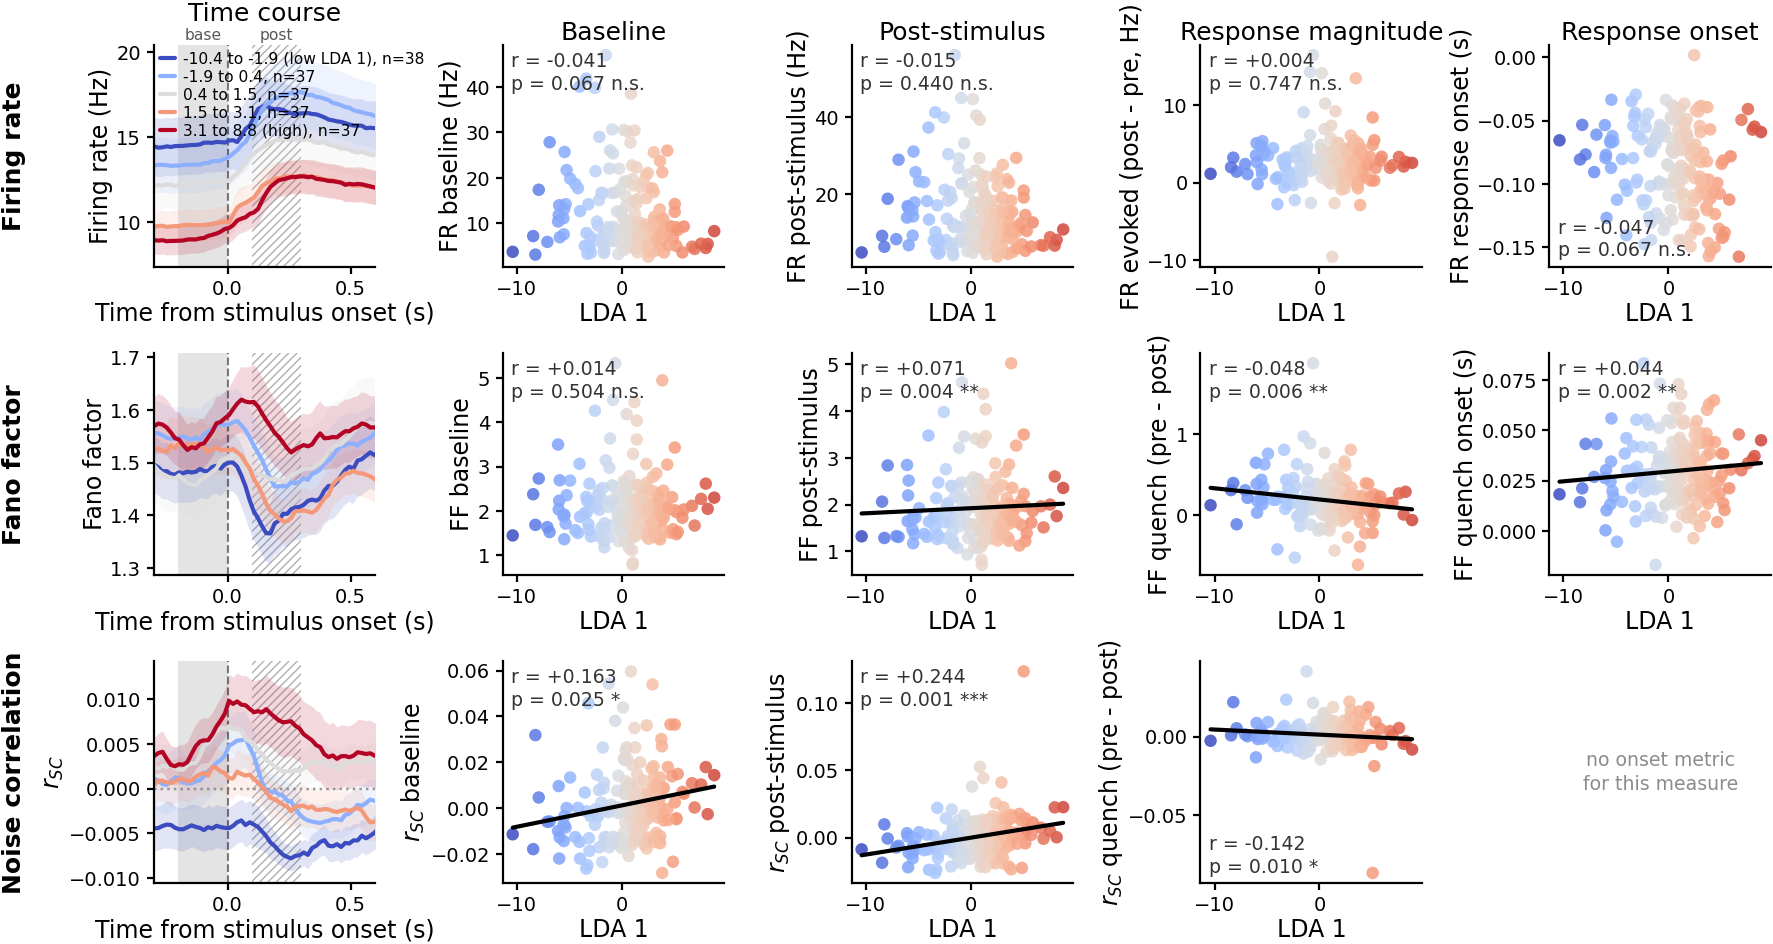

In [ ]:
ps.reapply()

# ONE FIGURE PER COMPONENT in COMPONENTS (cell above). Each is built from that component's
# own results frame, so its PSTH bins, its scatters and its annotated statistics all refer
# to the same axis; the file name carries the component so LD2's figure cannot overwrite
# LD1's.
for pred in COMPONENTS:
    res_c = res_by_comp[pred]
    res_ix = {(r['metric'], r['test']): r for _, r in res_c.iterrows()}

    fig, axes = panels(len(nm.METRIC_ROWS), len(nm.FIG_COLS))

    for i, metric in enumerate(nm.METRIC_ROWS):
        for j, col in enumerate(nm.FIG_COLS):
            ax = axes[i, j]
            if col == 'PSTH':
                psth_panel(ax, tables['curves'], metric, name_windows=(i == 0),
                           legend=(i == 0), predictor=pred)
            elif (metric, col) in res_ix:
                scatter_panel(ax, tables, res_ix[(metric, col)])
            else:
                blank_panel(ax, 'no onset metric\nfor this measure')
            if i == 0:
                # no fontsize override: axes.titlesize is 18 pt in poster mode, which is
                # what every other titled panel on the poster uses
                ax.set_title({'PSTH': 'Time course'}.get(col, col),
                             pad=plt.rcParams['axes.titlepad'] * (5 if col == 'PSTH' else 1))

    fig.tight_layout()

    # row names, placed after tight_layout so they sit on the real row centres
    for i, metric in enumerate(nm.METRIC_ROWS):
        box = axes[i, 0].get_position()
        fig.text(0.004, (box.y0 + box.y1) / 2, metric, rotation=90, va='center', ha='left',
                 fontsize=plt.rcParams['axes.titlesize'], fontweight='bold')
    fig.subplots_adjust(left=fig.subplotpars.left + 0.015)

    # 'neural_lda1_summary' is kept for component 1 so the paper's existing file name does
    # not move; the others are named after their own component
    _stem = 'neural_lda1_summary' if pred == 'lda_1' else f'neural_{pred}_summary'
    ps.savefig(fig, _stem, svg=True)
    plt.show()

## The correction, as a table to keep

The same numbers as the figure, written out so they can go into the manuscript or a
supplementary table without being re-read off the panels. Both families are written out:
`q_fdr_metric` / `q_holm_metric` correct within a metric, `q_fdr_all` / `q_holm_all` across all
ten, and `family` records which of the two the figure annotated.

In [ ]:
# res_all, not res: with one component the two are the same frame, and with more the
# csv then holds every test that was run rather than only the first component's.
out = res_all[['predictor', 'metric', 'test', 'unit', 'n', 'n_sessions', 'y_col',
           'region_col', 'covars',
           'slope', 'r_partial', 'bf10', 'evidence', 'p_perm',
           'q_fdr_metric', 'q_holm_metric', 'q_fdr_all', 'q_holm_all',
           'family', 'n_family', 'fdr_sig', 'significant']].copy()
p = ps.FIGDIR / f"neural_lda_summary_stats_{pd.Timestamp.today().strftime('%d-%m-%Y')}.csv"
p.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(p, index=False)
print('wrote', p)
out

wrote /home/ines/repositories/representation_learning_variability/paper-individuality/figures/neural_lda_summary_stats_18-09-2026.csv


,predictor,metric,test,unit,n,n_sessions,y_col,region_col,covars,slope,...,evidence,p_perm,q_fdr_metric,q_holm_metric,q_fdr_all,q_holm_all,family,n_family,fdr_sig,significant
0,lda_1,Firing rate,Baseline,neuron,13717,186,log_fr_pre,region,n_trials,-0.018015,...,strong H1,0.0665,0.133000,0.2660,0.091438,0.3325,metric,4,False,False
1,lda_1,Firing rate,Post-stimulus,neuron,13717,186,log_fr_post,region,n_trials,-0.006368,...,strong H0,0.4400,0.586667,0.8800,0.537778,1.0000,metric,4,False,False
2,lda_1,Firing rate,Response magnitude,neuron,13717,186,fr_evoked,region,n_trials,0.013157,...,strong H0,0.7470,0.747000,0.8800,0.747000,1.0000,metric,4,False,False
3,lda_1,Firing rate,Response onset,neuron,10555,186,fr_onset_time,region,n_trials,-0.001290,...,strong H1,0.0665,0.133000,0.2660,0.091438,0.3325,metric,4,False,False
4,lda_1,Fano factor,Baseline,neuron,11721,186,log_ff_pre,region,n_trials,0.002912,...,strong H0,0.5040,0.504000,0.5040,0.554400,1.0000,metric,4,False,False
5,lda_1,Fano factor,Post-stimulus,neuron,11721,186,log_ff_post,region,n_trials,0.013578,...,strong H1,0.0040,0.008000,0.0120,0.014667,0.0360,metric,4,True,True
6,lda_1,Fano factor,Response magnitude,neuron,11721,186,ff_quench,region,n_trials,-0.014605,...,strong H1,0.0060,0.008000,0.0120,0.016500,0.0480,metric,4,True,True
7,lda_1,Fano factor,Response onset,neuron,11679,186,quench_onset_time,region,n_trials,0.000941,...,strong H1,0.0015,0.006000,0.0060,0.008250,0.0150,metric,4,True,True
8,lda_1,Noise correlation,Baseline,session-region,398,185,r_sc_pre,region,n_trials + n_neurons,0.000849,...,moderate H1,0.0250,0.025000,0.0250,0.045833,0.1500,metric,3,True,True
9,lda_1,Noise correlation,Post-stimulus,session-region,398,185,r_sc_post,region,n_trials + n_neurons,0.001250,...,strong H1,0.0005,0.001500,0.0015,0.005500,0.0055,metric,3,True,True
